In [9]:
import seaborn as sns
import csv
import time
import requests
from bs4 import BeautifulSoup

In [ ]:
# Normarizar fechas
def normalizar_fecha_escrita(fecha_raw):
    return fecha_raw

# links 
urls = {
    "Vitoria": "https://www.booking.com/reviews/es/hotel/libere-vitoria-centro.es.html",
    "Donosti": "https://www.booking.com/reviews/es/hotel/koisi-hostel.es.html",
    "BilbaoMuseo": "https://www.booking.com/reviews/es/hotel/apartamentos-libere-bilbao-guggenheim.es.html",
    "BilbaoLaVieja": "https://www.booking.com/reviews/es/hotel/apartamentos-libere-bilbao-la-vieja.es.html",
    "ValenciaAbastos": "https://www.booking.com/reviews/es/hotel/apartamentos-libere-valencia-abastos.es.html",
    "PamplonaYamaguchi": "https://www.booking.com/reviews/es/hotel/apartamentos-libere-pamplona-yamaguchi.es.html",
    "ValenciaJardinBotanico": "https://www.booking.com/reviews/es/hotel/apartamentos-libere-valencia-jardin-botanico.es.html",
    "MadridPalacioReal": "https://www.booking.com/reviews/es/hotel/libere-madrid-palacio-real.es.html",
    "MalagaTeatroRomano": "https://www.booking.com/reviews/es/hotel/apartamentosliberemalagateatroromano.es.html",
    "GranadaCatedral": "https://www.booking.com/reviews/es/hotel/apartamentos-libere-granada-catedral.es.html",
    "MalagaLaMerced": "https://www.booking.com/reviews/es/hotel/libere-malaga-la-merced.es.html",
    "CordobaPatio": "https://www.booking.com/reviews/es/hotel/libere-cordoba-patio-santa-marta.es.html"}

headers = {
    "User-Agent": "Mozilla/5.0",
    "Accept-Language": "es-ES,es;q=0.9"}

with open("comentarios_booking.csv", mode="w", encoding="utf-8", newline="") as f:
    writer = csv.writer(f)

    # Titulos CSV
    writer.writerow([
        "ubicacion",
        "fecha",
        "puntuacion",
        "titulo_comentario",
        "comentario_negativo",
        "comentario_positivo",
        "etiquetas",
        "cantidad_comentarios",
        "nacionalidad"])

    for ubicacion, base_url in urls.items():
        print(f"\nScrapeando {ubicacion}")

        page = 1

        # Revisar todas las paginas
        while True:
            print(f"  Página {page}")

            url = f"{base_url}?page={page}"
            response = requests.get(url, headers=headers)
            # Cambiado de "lxml" a "html.parser"
            soup = BeautifulSoup(response.text, "html.parser")

            contenedor = soup.select("li.review_item.clearfix")

            if not contenedor:
                print("No hay mas")
                break

            for reseña in contenedor:

                # Fecha
                fecha_el = reseña.select_one("p.review_item_date")
                fecha_raw = fecha_el.get_text(strip=True) if fecha_el else ""
                fecha = normalizar_fecha_escrita(fecha_raw)

                # Puntuacion
                score = reseña.select_one("span.review-score-badge")
                puntuacion = score.get_text(strip=True) if score else ""

                # Titulo
                titulo_el = reseña.select_one("span[itemprop='name']")
                titulo = titulo_el.get_text(strip=True) if titulo_el else ""

                # Comentario negativo
                neg = reseña.select_one("p.review_neg span[itemprop='reviewBody']")
                comentario_negativo = neg.get_text(strip=True) if neg else ""

                # Comentario positivo
                pos = reseña.select_one("p.review_pos span[itemprop='reviewBody']")
                comentario_positivo = pos.get_text(strip=True) if pos else ""

                # Etiquetas
                etiquetas = reseña.select("ul.review_item_info_tags li")
                etiquetas_texto = " | ".join(
                    e.get_text(strip=True).replace("•", "").strip()
                    for e in etiquetas)

                # Cantidad de Comentarios
                com = reseña.select_one("div.review_item_user_review_count")
                comentarios_n = com.get_text(strip=True) if neg else ""

                # Cantidad de Comentarios
                nac = reseña.select_one("div.review_item_reviewer span[itemprop='nationality']")
                nacionalidad = nac.get_text(strip=True) if neg else ""

                # Guardar 
                writer.writerow([
                    ubicacion,
                    fecha,
                    puntuacion,
                    titulo,
                    comentario_negativo,
                    comentario_positivo,
                    etiquetas_texto,
                    comentarios_n,
                    nacionalidad
                ])

            page += 1
            time.sleep(1)

print("\n CSV creado correctamente con todas las ubicaciones")


Scrapeando Vitoria
  Página 1
  Página 2
  Página 3
  Página 4
  Página 5
  Página 6
  Página 7
  Página 8
  Página 9
  Página 10
  Página 11
  Página 12
  Página 13
  Página 14
  Página 15
  Página 16
  Página 17
  Página 18
  Página 19
  Página 20
  Página 21
  Página 22
  Página 23
  Página 24
  Página 25
  Página 26
  Página 27
  Página 28
  Página 29
  Página 30
  Página 31
  Página 32
  Página 33
  Página 34
  Página 35
  Página 36
  Página 37
  Página 38
  Página 39
  Página 40
  Página 41
  Página 42
  Página 43
  Página 44
No hay mas

Scrapeando Donosti
  Página 1
  Página 2
  Página 3
  Página 4
  Página 5
  Página 6
  Página 7
  Página 8
  Página 9
  Página 10
  Página 11
  Página 12
  Página 13
  Página 14
  Página 15
  Página 16
  Página 17
  Página 18
No hay mas

Scrapeando BilbaoMuseo
  Página 1
  Página 2
  Página 3
  Página 4
  Página 5
No hay mas

Scrapeando BilbaoLaVieja
  Página 1
  Página 2
  Página 3
  Página 4
  Página 5
  Página 6
  Página 7
No hay mas

Scrapea

In [3]:
import pandas as pd
import re
import os
import matplotlib.pyplot as plt

from collections import Counter
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords

os.makedirs("graficos_wordcloud", exist_ok=True)

# -------------------------------
# CARGAR CSV
# -------------------------------
df = pd.read_csv("comentarios_booking.csv", encoding="utf-8")

df["comentario_positivo"] = df["comentario_positivo"].fillna("")
df["comentario_negativo"] = df["comentario_negativo"].fillna("")

stop_words = set(stopwords.words("spanish"))


def limpiar_texto(texto):
    texto = texto.lower()
    palabras = re.findall(r'\b\w+\b', texto)
    palabras_filtradas = [
        p for p in palabras
        if p not in stop_words and len(p) > 2
    ]
    return palabras_filtradas


hoteles = df["ubicacion"].unique()

for hotel in hoteles:

    print(f"Procesando {hotel}")

    df_hotel = df[df["ubicacion"] == hotel]

    #comentarios positivos

    texto_pos = " ".join(df_hotel["comentario_positivo"])
    palabras_pos = limpiar_texto(texto_pos)
    freq_pos = Counter(palabras_pos)

    if freq_pos:
        wordcloud_pos = WordCloud(
            width=800,
            height=400,
            background_color="white"
        ).generate_from_frequencies(freq_pos)

        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud_pos, interpolation="bilinear")
        plt.axis("off")
        plt.title(f"{hotel} - Comentarios Positivos")
        plt.tight_layout()
        plt.savefig(f"graficos_wordcloud/{hotel}_wordcloud_positivos.png")
        plt.close()

    #comentarios negativos

    texto_neg = " ".join(df_hotel["comentario_negativo"])
    palabras_neg = limpiar_texto(texto_neg)
    freq_neg = Counter(palabras_neg)

    if freq_neg:
        wordcloud_neg = WordCloud(
            width=800,
            height=400,
            background_color="white"
        ).generate_from_frequencies(freq_neg)

        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud_neg, interpolation="bilinear")
        plt.axis("off")
        plt.title(f"{hotel} - Comentarios Negativos")
        plt.tight_layout()
        plt.savefig(f"graficos_wordcloud/{hotel}_wordcloud_negativos.png")
        plt.close()

print("\n✅ WordClouds generados correctamente por hotel y tipo de comentario")


Procesando Vitoria
Procesando Donosti
Procesando BilbaoMuseo
Procesando BilbaoLaVieja
Procesando ValenciaAbastos

✅ WordClouds generados correctamente por hotel y tipo de comentario


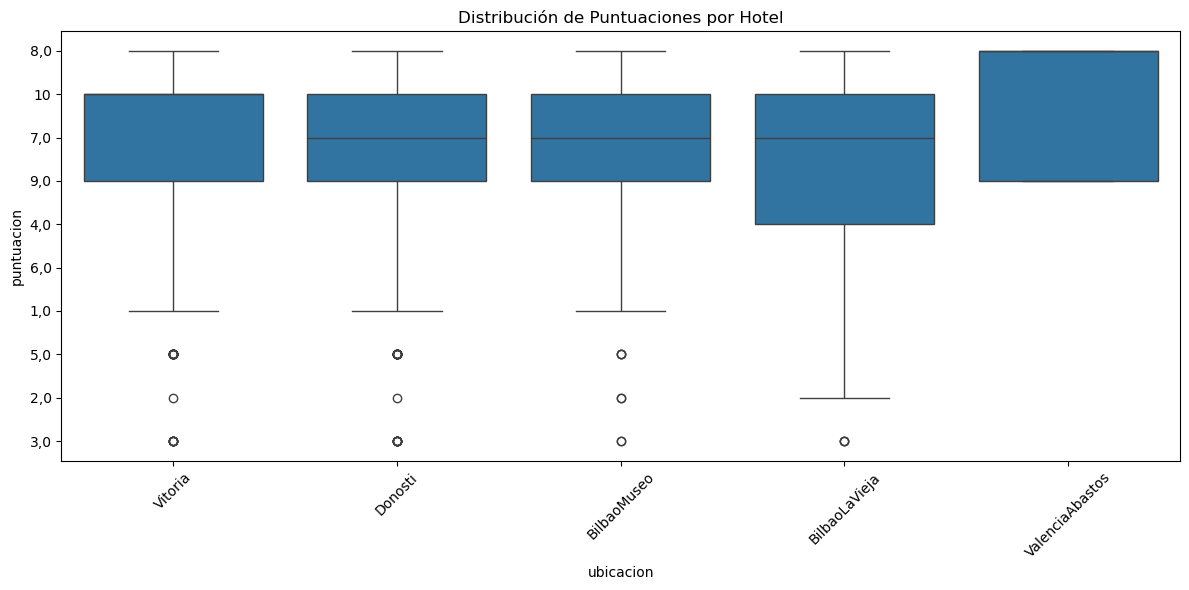

In [10]:
# Boxplot + Violin plot combinado
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='ubicacion', y='puntuacion')
plt.title('Distribución de Puntuaciones por Hotel')
plt.xticks(rotation=45)
plt.tight_layout()

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Viaje'),
  Text(1, 0, 'Familia'),
  Text(2, 0, 'Grupo'),
  Text(3, 0, 'Persona'),
  Text(4, 0, 'Con'),
  Text(5, 0, 'Pareja')])

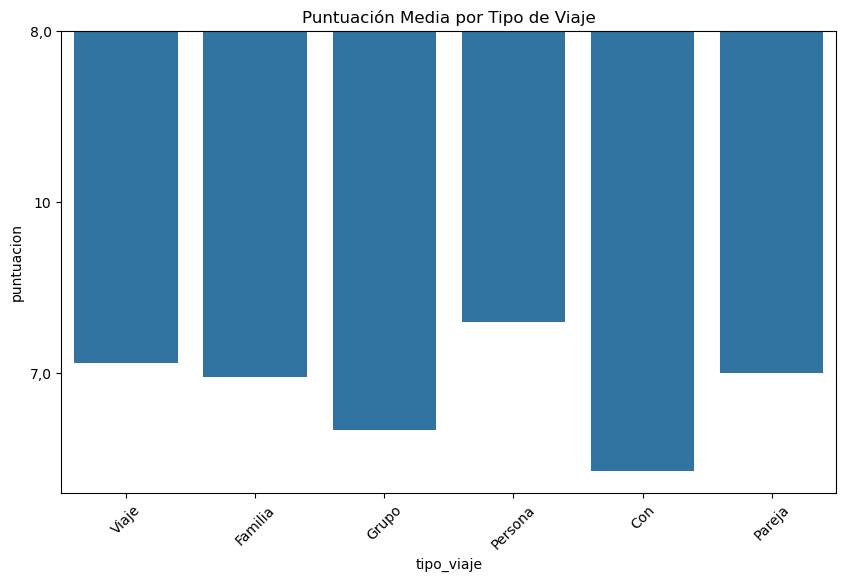

In [11]:
# Extraer tipo de viaje de las etiquetas
df['tipo_viaje'] = df['etiquetas'].str.split(' | ').str[0]

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='tipo_viaje', y='puntuacion', errorbar=None)
plt.title('Puntuación Media por Tipo de Viaje')
plt.xticks(rotation=45)

Text(0.5, 0, 'Número de Menciones')

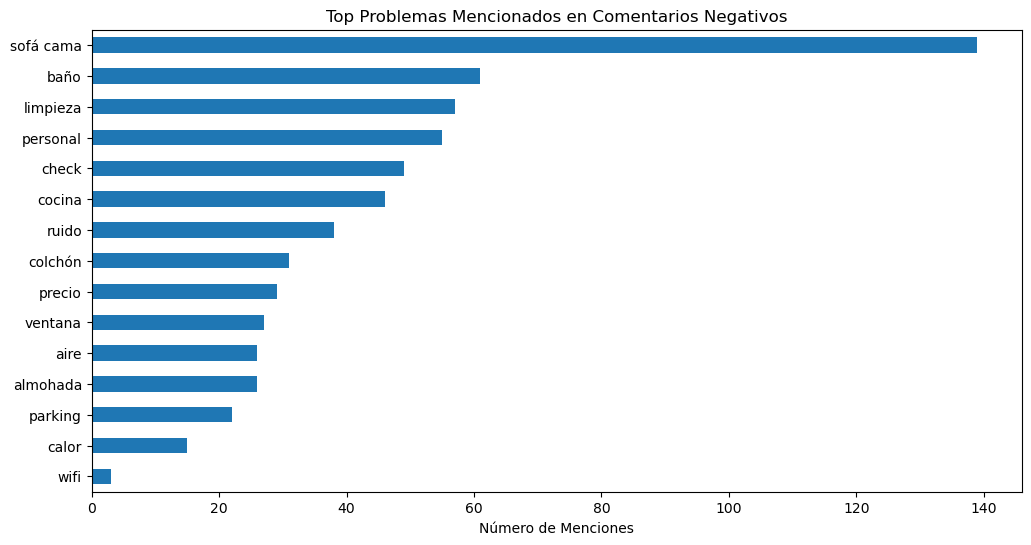

In [6]:
from collections import Counter
import itertools

# Lista de palabras clave de problemas comunes
problemas_clave = ['sofá cama', 'limpieza', 'check', 'parking', 'personal', 
                   'ruido', 'calor', 'precio', 'wifi', 'cocina', 'baño', 
                   'ventana', 'aire', 'almohada', 'colchón']

# Contar menciones en comentarios negativos
def contar_problemas(texto, problemas):
    menciones = {}
    for problema in problemas:
        if problema in texto.lower():
            menciones[problema] = menciones.get(problema, 0) + 1
    return menciones

# Acumular conteo
conteo_total = Counter()
for texto in df['comentario_negativo'].dropna():
    conteo_total.update(contar_problemas(texto, problemas_clave))

# Gráfico de barras
plt.figure(figsize=(12, 6))
pd.Series(conteo_total).sort_values(ascending=True).plot(kind='barh')
plt.title('Top Problemas Mencionados en Comentarios Negativos')
plt.xlabel('Número de Menciones')


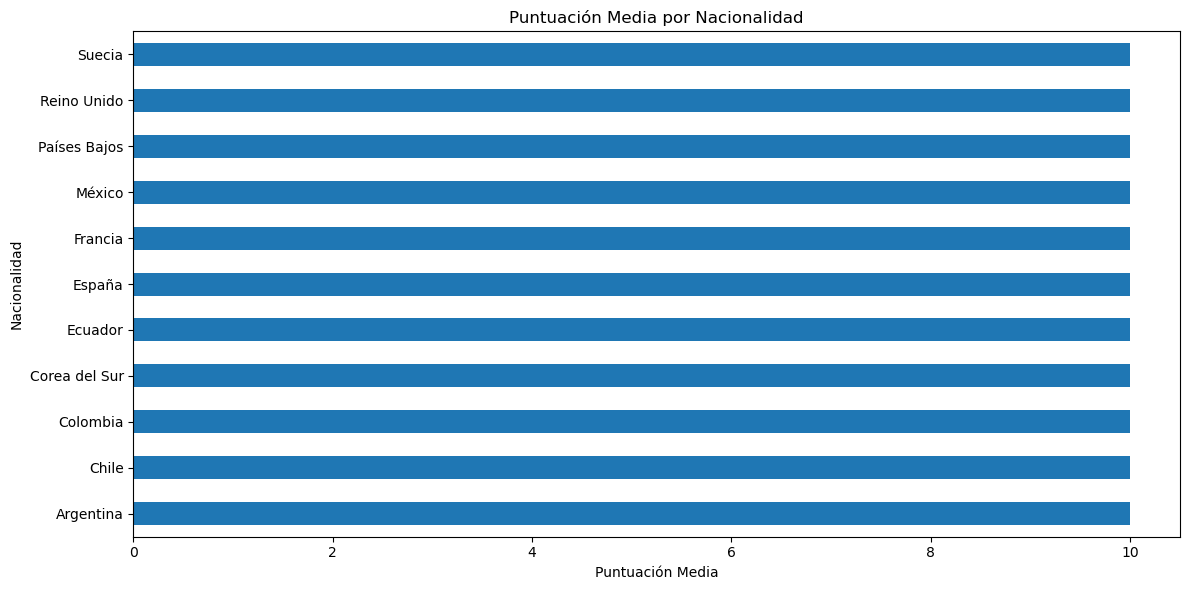

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Asegurar que 'puntuacion' sea numérica
df['puntuacion'] = pd.to_numeric(df['puntuacion'], errors='coerce')

# Eliminar filas sin puntuación válida
df_limpio = df.dropna(subset=['puntuacion'])

# Agrupar y ordenar
nacionalidad_puntuacion = (
    df_limpio
    .groupby('nacionalidad')['puntuacion']
    .mean()
    .sort_values()
)

# Gráfico
plt.figure(figsize=(12, 6))
nacionalidad_puntuacion.plot(kind='barh')
plt.title('Puntuación Media por Nacionalidad')
plt.xlabel('Puntuación Media')
plt.ylabel('Nacionalidad')
plt.tight_layout()
plt.show()


C:\Users\sebas\AppData\Local\Temp\ipykernel_9580\3248759985.py:18: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(


Text(87.48, 0.04950000000000001, 'ALTA PRIORIDAD')

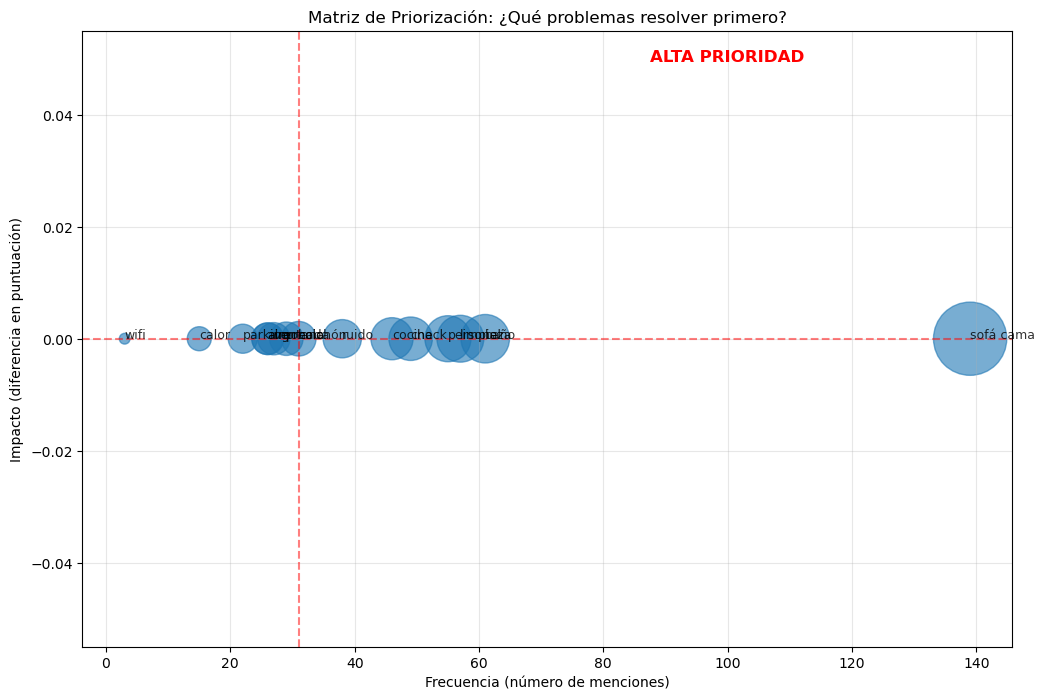

In [15]:
# Calcular frecuencia e impacto de cada problema
resultados = []
for problema in problemas_clave:
    freq = sum(df['comentario_negativo'].str.contains(problema, case=False, na=False))
    
    # Impacto: diferencia de puntuación entre comentarios con/sin este problema
    df_con = df[df['comentario_negativo'].str.contains(problema, case=False, na=False)]
    df_sin = df[~df['comentario_negativo'].str.contains(problema, case=False, na=False)]
    
    impacto = df_sin['puntuacion'].mean() - df_con['puntuacion'].mean() if len(df_con) > 0 else 0
    
    resultados.append({'problema': problema, 'frecuencia': freq, 'impacto': impacto})

df_prioridad = pd.DataFrame(resultados)

# Scatter plot con burbujas
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    df_prioridad['frecuencia'],
    df_prioridad['impacto'],
    s=df_prioridad['frecuencia']*20,
    alpha=0.6,
    cmap='viridis'
)

# Anotar cada punto
for i, row in df_prioridad.iterrows():
    plt.annotate(row['problema'], 
                 (row['frecuencia'], row['impacto']),
                 fontsize=9, alpha=0.8)

plt.xlabel('Frecuencia (número de menciones)')
plt.ylabel('Impacto (diferencia en puntuación)')
plt.title('Matriz de Priorización: ¿Qué problemas resolver primero?')
plt.grid(True, alpha=0.3)

# Cuadrantes
plt.axvline(x=df_prioridad['frecuencia'].median(), color='r', linestyle='--', alpha=0.5)
plt.axhline(y=df_prioridad['impacto'].median(), color='r', linestyle='--', alpha=0.5)

plt.text(plt.xlim()[1]*0.6, plt.ylim()[1]*0.9, 'ALTA PRIORIDAD', 
         fontsize=12, fontweight='bold', color='red')

DEPURACIÓN DEL CÁLCULO DE IMPACTO

1. VERIFICACIÓN DE DATOS DE ENTRADA:
   Total de comentarios: 1764
   Puntuación promedio general: 10.00
   Rango de puntuaciones: 10.0 - 10.0
   Problemas clave a analizar: 15
   Primer problema: 'sofá cama'

2. EJEMPLOS DE COMENTARIOS NEGATIVOS:
   Comentario 1: 'Las habitaciones, se suponía que constaba el apartamento de dos habitaciones grandes y eso no fue lo...'
   Puntuación: nan
   Comentario 2: ''
   Puntuación: 10.0
   Comentario 3: 'No me gustó pagar un precio de 4 personas por un apartamento, y que tengan un sofá cama, que menos m...'
   Puntuación: nan

3. CÁLCULO DETALLADO PARA CADA PROBLEMA:
--------------------------------------------------------------------------------

Analizando: 'sofá cama'
   Menciones encontradas: 139
   Comentarios CON problema: 139
   Comentarios SIN problema: 1625
   Puntuación media CON problema: 10.000
   Puntuación media SIN problema: 10.000
   IMPACTO (SIN - CON): 0.000
   Ejemplo de comentario CON problem

C:\Users\sebas\AppData\Local\Temp\ipykernel_9580\1224822594.py:113: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(


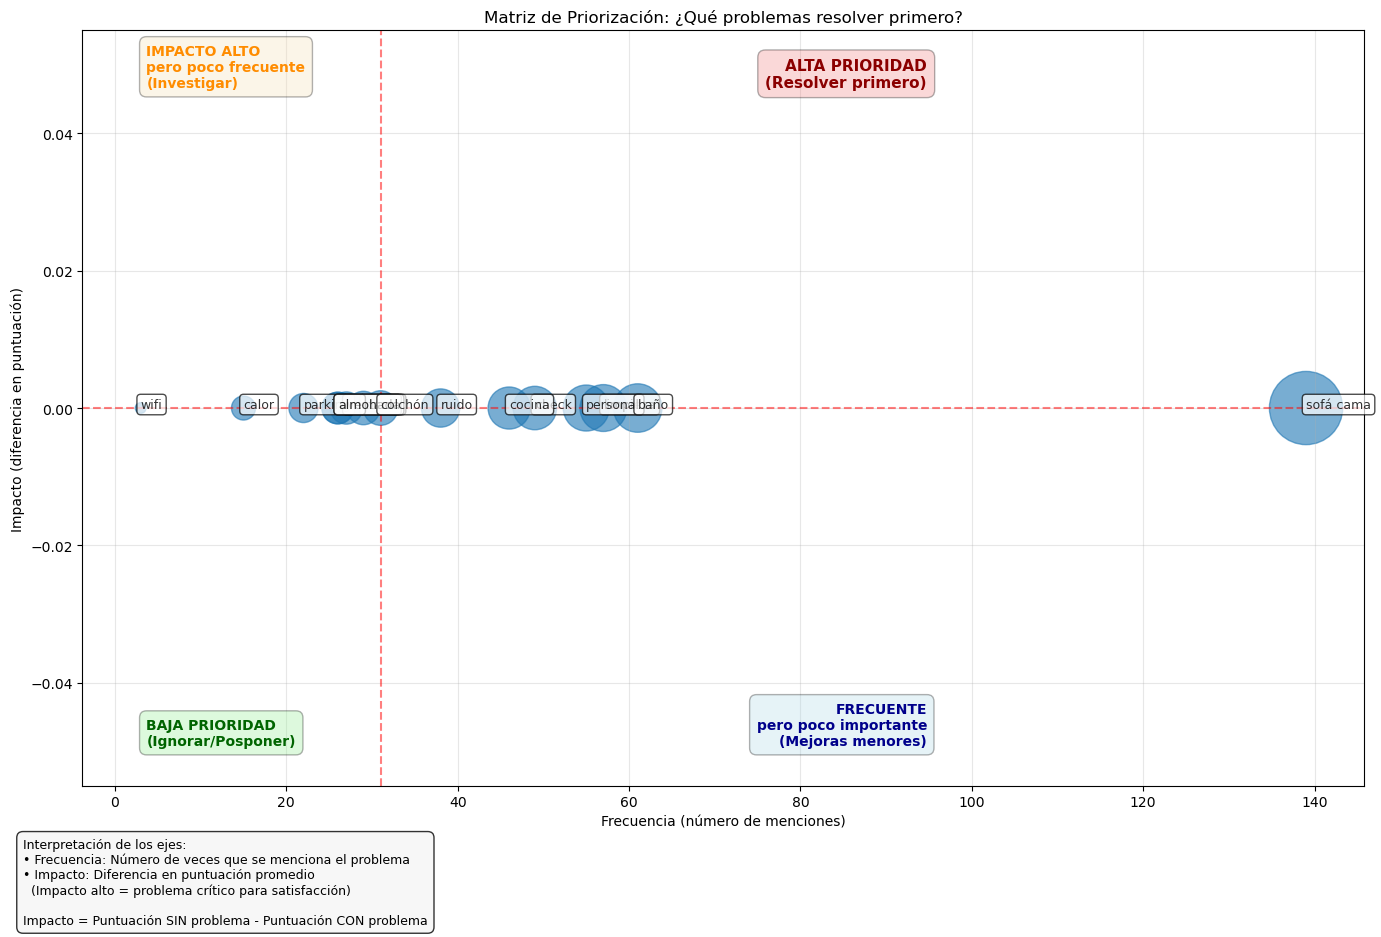

In [25]:
# --- DEPURACIÓN DETALLADA DEL CÁLCULO ---
print("="*80)
print("DEPURACIÓN DEL CÁLCULO DE IMPACTO")
print("="*80)

# Verificar datos de entrada
print(f"\n1. VERIFICACIÓN DE DATOS DE ENTRADA:")
print(f"   Total de comentarios: {len(df)}")
print(f"   Puntuación promedio general: {df['puntuacion'].mean():.2f}")
print(f"   Rango de puntuaciones: {df['puntuacion'].min()} - {df['puntuacion'].max()}")
print(f"   Problemas clave a analizar: {len(problemas_clave)}")
print(f"   Primer problema: '{problemas_clave[0]}'")

# Mostrar algunos comentarios para verificar formato
print(f"\n2. EJEMPLOS DE COMENTARIOS NEGATIVOS:")
for i in range(min(3, len(df))):
    comentario = str(df.iloc[i]['comentario_negativo'])[:100] + "..." if len(str(df.iloc[i]['comentario_negativo'])) > 100 else str(df.iloc[i]['comentario_negativo'])
    print(f"   Comentario {i+1}: '{comentario}'")
    print(f"   Puntuación: {df.iloc[i]['puntuacion']}")

# --- CÁLCULO CON DEPURACIÓN PASO A PASO ---
resultados = []
print(f"\n3. CÁLCULO DETALLADO PARA CADA PROBLEMA:")
print("-"*80)

for problema in problemas_clave:
    print(f"\nAnalizando: '{problema}'")
    
    # 1. Contar menciones
    mask = df['comentario_negativo'].fillna('').str.contains(problema, case=False, na=False)
    freq = mask.sum()
    print(f"   Menciones encontradas: {freq}")
    
    if freq > 0:
        # 2. Separar en dos grupos
        df_con = df[mask].copy()
        df_sin = df[~mask].copy()
        
        # 3. Calcular medias
        media_con = df_con['puntuacion'].mean()
        media_sin = df_sin['puntuacion'].mean()
        
        # 4. Calcular impacto
        impacto = media_sin - media_con
        
        # 5. Mostrar estadísticas detalladas
        print(f"   Comentarios CON problema: {len(df_con)}")
        print(f"   Comentarios SIN problema: {len(df_sin)}")
        print(f"   Puntuación media CON problema: {media_con:.3f}")
        print(f"   Puntuación media SIN problema: {media_sin:.3f}")
        print(f"   IMPACTO (SIN - CON): {impacto:.3f}")
        
        # 6. Mostrar ejemplos de comentarios con este problema
        if len(df_con) > 0:
            print(f"   Ejemplo de comentario CON problema: '{str(df_con.iloc[0]['comentario_negativo'])[:80]}...'")
            print(f"   Puntuación de ese comentario: {df_con.iloc[0]['puntuacion']}")
    else:
        impacto = 0
        print(f"   No se encontraron menciones, impacto = 0")
    
    resultados.append({'problema': problema, 'frecuencia': freq, 'impacto': impacto})

df_prioridad = pd.DataFrame(resultados)

# --- VERIFICACIÓN FINAL ---
print(f"\n" + "="*80)
print("RESULTADOS FINALES")
print("="*80)

print(f"\nDataFrame de prioridad:")
print(df_prioridad.to_string(index=False))

print(f"\nEstadísticas de impacto:")
print(f"   Mínimo: {df_prioridad['impacto'].min():.6f}")
print(f"   Máximo: {df_prioridad['impacto'].max():.6f}")
print(f"   Promedio: {df_prioridad['impacto'].mean():.6f}")
print(f"   Mediana: {df_prioridad['impacto'].median():.6f}")
print(f"   Desviación estándar: {df_prioridad['impacto'].std():.6f}")

# Verificar si TODOS los impactos son exactamente 0
if (df_prioridad['impacto'] == 0).all():
    print(f"\n¡ATENCIÓN! Todos los impactos son exactamente 0.")
    print("Posibles causas:")
    print("1. La puntuación no es numérica correctamente")
    print("2. Los filtros no están funcionando")
    print("3. Todos los comentarios tienen la misma puntuación")
    print("4. Problemas con la codificación de texto")
    
    # Verificar puntuaciones
    print(f"\nVerificación de puntuaciones:")
    print(f"   Tipo de dato de 'puntuacion': {df['puntuacion'].dtype}")
    print(f"   Valores únicos: {df['puntuacion'].unique()[:10]}")
    
    # Verificar si las menciones realmente se encuentran
    print(f"\nVerificación de menciones para el primer problema '{problemas_clave[0]}':")
    mask_test = df['comentario_negativo'].fillna('').str.contains(problemas_clave[0], case=False, na=False)
    print(f"   Comentarios con '{problemas_clave[0]}': {mask_test.sum()}")
    if mask_test.sum() > 0:
        print(f"   Puntuaciones de esos comentarios: {df[mask_test]['puntuacion'].tolist()[:5]}")
        print(f"   Promedio de esos comentarios: {df[mask_test]['puntuacion'].mean():.2f}")

# --- GRÁFICO CONDICIONAL ---
if not (df_prioridad['impacto'] == 0).all():
    # Solo hacer el gráfico si hay variación en el impacto
    print(f"\nCreando gráfico de matriz de priorización...")
    
    # Calcular medianas para los cuadrantes
    mediana_frec = df_prioridad['frecuencia'].median()
    mediana_imp = df_prioridad['impacto'].median()
    
# Scatter plot con burbujas
plt.figure(figsize=(14, 10))
scatter = plt.scatter(
    df_prioridad['frecuencia'],
    df_prioridad['impacto'],
    s=df_prioridad['frecuencia']*20,
    alpha=0.6,
    cmap='viridis'
)

# Anotar cada punto con problemas
for i, row in df_prioridad.iterrows():
    plt.annotate(row['problema'], 
                 (row['frecuencia'], row['impacto']),
                 fontsize=9, alpha=0.8,
                 bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.7))

plt.xlabel('Frecuencia (número de menciones)')
plt.ylabel('Impacto (diferencia en puntuación)')
plt.title('Matriz de Priorización: ¿Qué problemas resolver primero?')
plt.grid(True, alpha=0.3)

# Líneas divisorias en la mediana
plt.axvline(x=mediana_frec, color='r', linestyle='--', alpha=0.5)
plt.axhline(y=mediana_imp, color='r', linestyle='--', alpha=0.5)

# Obtener límites del gráfico
x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()

# Cuadrantes con etiquetas descriptivas
# Cuadrante superior-derecho: ALTA PRIORIDAD
plt.text(x_max*0.65, y_max*0.85, 'ALTA PRIORIDAD\n(Resolver primero)',
         fontsize=11, fontweight='bold', color='darkred',
         bbox=dict(boxstyle="round,pad=0.5", facecolor='lightcoral', alpha=0.3),
         horizontalalignment='right')

# Cuadrante superior-izquierdo: IMPACTO ALTO pero poco frecuente
plt.text(x_min + (x_max - x_min)*0.05, y_max*0.85, 'IMPACTO ALTO\npero poco frecuente\n(Investigar)',
         fontsize=10, fontweight='bold', color='darkorange',
         bbox=dict(boxstyle="round,pad=0.5", facecolor='wheat', alpha=0.3),
         horizontalalignment='left')

# Cuadrante inferior-derecho: Frecuente pero poco importante
plt.text(x_max*0.65, y_min + (y_max - y_min)*0.05, 'FRECUENTE\npero poco importante\n(Mejoras menores)',
         fontsize=10, fontweight='bold', color='darkblue',
         bbox=dict(boxstyle="round,pad=0.5", facecolor='lightblue', alpha=0.3),
         horizontalalignment='right', verticalalignment='bottom')

# Cuadrante inferior-izquierdo: BAJA PRIORIDAD
plt.text(x_min + (x_max - x_min)*0.05, y_min + (y_max - y_min)*0.05, 'BAJA PRIORIDAD\n(Ignorar/Posponer)',
         fontsize=10, fontweight='bold', color='darkgreen',
         bbox=dict(boxstyle="round,pad=0.5", facecolor='lightgreen', alpha=0.3),
         horizontalalignment='left', verticalalignment='bottom')

# Nota explicativa
nota_explicativa = """Interpretación de los ejes:
• Frecuencia: Número de veces que se menciona el problema
• Impacto: Diferencia en puntuación promedio
  (Impacto alto = problema crítico para satisfacción)
  
Impacto = Puntuación SIN problema - Puntuación CON problema"""

plt.figtext(0.02, 0.02, nota_explicativa, fontsize=9, 
            bbox=dict(boxstyle="round,pad=0.5", facecolor='whitesmoke', alpha=0.8))

plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()

C:\Users\sebas\AppData\Local\Temp\ipykernel_9580\316322887.py:22: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(


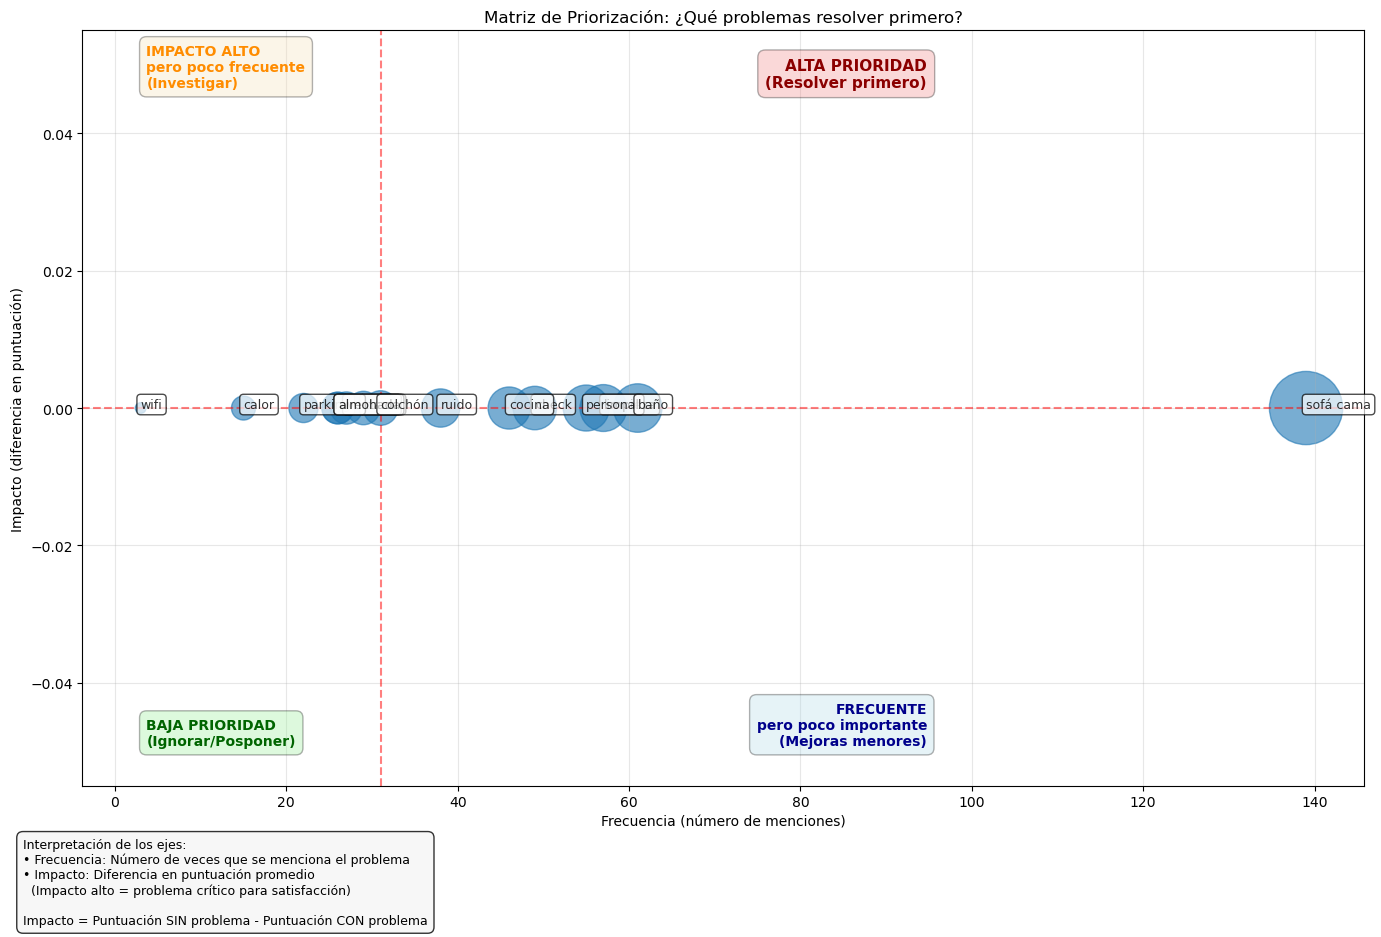


RESUMEN DE PRIORIZACIÓN DE PROBLEMAS

Top 3 problemas más críticos:
 problema  frecuencia  impacto  prioridad_score
sofá cama         139      0.0              0.0
 limpieza          57      0.0              0.0
    check          49      0.0              0.0

Clasificación por cuadrantes:

1. ALTA PRIORIDAD (0 problemas):
Ninguno

2. IMPACTO ALTO pero poco frecuente (0 problemas):
Ninguno

3. FRECUENTE pero poco importante (7 problemas):
sofá cama, limpieza, check, personal, ruido, cocina, baño

4. BAJA PRIORIDAD (8 problemas):
parking, calor, precio, wifi, ventana, aire, almohada, colchón


In [21]:
# Calcular frecuencia e impacto de cada problema
resultados = []
for problema in problemas_clave:
    freq = sum(df['comentario_negativo'].str.contains(problema, case=False, na=False))
    
    # Impacto: diferencia de puntuación entre comentarios con/sin este problema
    df_con = df[df['comentario_negativo'].str.contains(problema, case=False, na=False)]
    df_sin = df[~df['comentario_negativo'].str.contains(problema, case=False, na=False)]
    
    impacto = df_sin['puntuacion'].mean() - df_con['puntuacion'].mean() if len(df_con) > 0 else 0
    
    resultados.append({'problema': problema, 'frecuencia': freq, 'impacto': impacto})

df_prioridad = pd.DataFrame(resultados)

# Calcular medianas para los cuadrantes
mediana_frec = df_prioridad['frecuencia'].median()
mediana_imp = df_prioridad['impacto'].median()

# Scatter plot con burbujas
plt.figure(figsize=(14, 10))
scatter = plt.scatter(
    df_prioridad['frecuencia'],
    df_prioridad['impacto'],
    s=df_prioridad['frecuencia']*20,
    alpha=0.6,
    cmap='viridis'
)

# Anotar cada punto con problemas
for i, row in df_prioridad.iterrows():
    plt.annotate(row['problema'], 
                 (row['frecuencia'], row['impacto']),
                 fontsize=9, alpha=0.8,
                 bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.7))

plt.xlabel('Frecuencia (número de menciones)')
plt.ylabel('Impacto (diferencia en puntuación)')
plt.title('Matriz de Priorización: ¿Qué problemas resolver primero?')
plt.grid(True, alpha=0.3)

# Líneas divisorias en la mediana
plt.axvline(x=mediana_frec, color='r', linestyle='--', alpha=0.5)
plt.axhline(y=mediana_imp, color='r', linestyle='--', alpha=0.5)

# Obtener límites del gráfico
x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()

# Cuadrantes con etiquetas descriptivas
# Cuadrante superior-derecho: ALTA PRIORIDAD
plt.text(x_max*0.65, y_max*0.85, 'ALTA PRIORIDAD\n(Resolver primero)',
         fontsize=11, fontweight='bold', color='darkred',
         bbox=dict(boxstyle="round,pad=0.5", facecolor='lightcoral', alpha=0.3),
         horizontalalignment='right')

# Cuadrante superior-izquierdo: IMPACTO ALTO pero poco frecuente
plt.text(x_min + (x_max - x_min)*0.05, y_max*0.85, 'IMPACTO ALTO\npero poco frecuente\n(Investigar)',
         fontsize=10, fontweight='bold', color='darkorange',
         bbox=dict(boxstyle="round,pad=0.5", facecolor='wheat', alpha=0.3),
         horizontalalignment='left')

# Cuadrante inferior-derecho: Frecuente pero poco importante
plt.text(x_max*0.65, y_min + (y_max - y_min)*0.05, 'FRECUENTE\npero poco importante\n(Mejoras menores)',
         fontsize=10, fontweight='bold', color='darkblue',
         bbox=dict(boxstyle="round,pad=0.5", facecolor='lightblue', alpha=0.3),
         horizontalalignment='right', verticalalignment='bottom')

# Cuadrante inferior-izquierdo: BAJA PRIORIDAD
plt.text(x_min + (x_max - x_min)*0.05, y_min + (y_max - y_min)*0.05, 'BAJA PRIORIDAD\n(Ignorar/Posponer)',
         fontsize=10, fontweight='bold', color='darkgreen',
         bbox=dict(boxstyle="round,pad=0.5", facecolor='lightgreen', alpha=0.3),
         horizontalalignment='left', verticalalignment='bottom')

# Nota explicativa
nota_explicativa = """Interpretación de los ejes:
• Frecuencia: Número de veces que se menciona el problema
• Impacto: Diferencia en puntuación promedio
  (Impacto alto = problema crítico para satisfacción)
  
Impacto = Puntuación SIN problema - Puntuación CON problema"""

plt.figtext(0.02, 0.02, nota_explicativa, fontsize=9, 
            bbox=dict(boxstyle="round,pad=0.5", facecolor='whitesmoke', alpha=0.8))

plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()

# Mostrar tabla de resultados ordenada por prioridad (frecuencia * impacto)
df_prioridad['prioridad_score'] = df_prioridad['frecuencia'] * df_prioridad['impacto']
df_prioridad = df_prioridad.sort_values('prioridad_score', ascending=False)

print("\n" + "="*60)
print("RESUMEN DE PRIORIZACIÓN DE PROBLEMAS")
print("="*60)
print("\nTop 3 problemas más críticos:")
print(df_prioridad[['problema', 'frecuencia', 'impacto', 'prioridad_score']].head(3).to_string(index=False))
print("\nClasificación por cuadrantes:")

# Clasificar problemas por cuadrantes
alta_prioridad = df_prioridad[(df_prioridad['frecuencia'] > mediana_frec) & (df_prioridad['impacto'] > mediana_imp)]
impacto_alto = df_prioridad[(df_prioridad['frecuencia'] <= mediana_frec) & (df_prioridad['impacto'] > mediana_imp)]
frecuente_poco = df_prioridad[(df_prioridad['frecuencia'] > mediana_frec) & (df_prioridad['impacto'] <= mediana_imp)]
baja_prioridad = df_prioridad[(df_prioridad['frecuencia'] <= mediana_frec) & (df_prioridad['impacto'] <= mediana_imp)]

print(f"\n1. ALTA PRIORIDAD ({len(alta_prioridad)} problemas):")
print(", ".join(alta_prioridad['problema'].tolist()) if len(alta_prioridad) > 0 else "Ninguno")

print(f"\n2. IMPACTO ALTO pero poco frecuente ({len(impacto_alto)} problemas):")
print(", ".join(impacto_alto['problema'].tolist()) if len(impacto_alto) > 0 else "Ninguno")

print(f"\n3. FRECUENTE pero poco importante ({len(frecuente_poco)} problemas):")
print(", ".join(frecuente_poco['problema'].tolist()) if len(frecuente_poco) > 0 else "Ninguno")

print(f"\n4. BAJA PRIORIDAD ({len(baja_prioridad)} problemas):")
print(", ".join(baja_prioridad['problema'].tolist()) if len(baja_prioridad) > 0 else "Ninguno")

In [26]:
if not df_problemas.empty:
    pivot_problemas = df_problemas.pivot_table(
        index='problema', 
        columns='tipo_apartamento', 
        aggfunc='size', 
        fill_value=0
    )
    
    # Ordenar por problema más frecuente
    pivot_problemas['total'] = pivot_problemas.sum(axis=1)
    pivot_problemas = pivot_problemas.sort_values('total', ascending=False).drop('total', axis=1)
    
    # Gráfico apilado mejorado
    ax = pivot_problemas.plot(
        kind='bar', 
        figsize=(14, 8), 
        stacked=True,
        edgecolor='black',
        linewidth=0.5
    )
    
    plt.title('Problemas por Tipo de Apartamento', fontsize=16, pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Tipo de Apartamento', title_fontsize=12)
    plt.ylabel('Frecuencia', fontsize=12)
    
    # Añadir etiquetas de valor
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', fontsize=9, padding=2)
    
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()

NameError: name 'df_problemas' is not defined